# Unit 2：ICA 算法原理 —— FastICA 详解

## 目标
- 理解 ICA 的目标函数：非高斯性最大化
- 掌握 FastICA 的迭代过程
- 理解白化（whitening）的作用


### 2.1 为什么「非高斯性」是关键？

**中心极限定理**：多个独立随机变量之和的分布，比任何一个单变量的分布**更高斯**。

混合信号 $X = AS$ 是多个源信号的加权和 → 比任何单源信号都更「高斯」。

所以 ICA 的思路是：**找到让信号「最非高斯」的方向 → 那就是源信号的方向。**


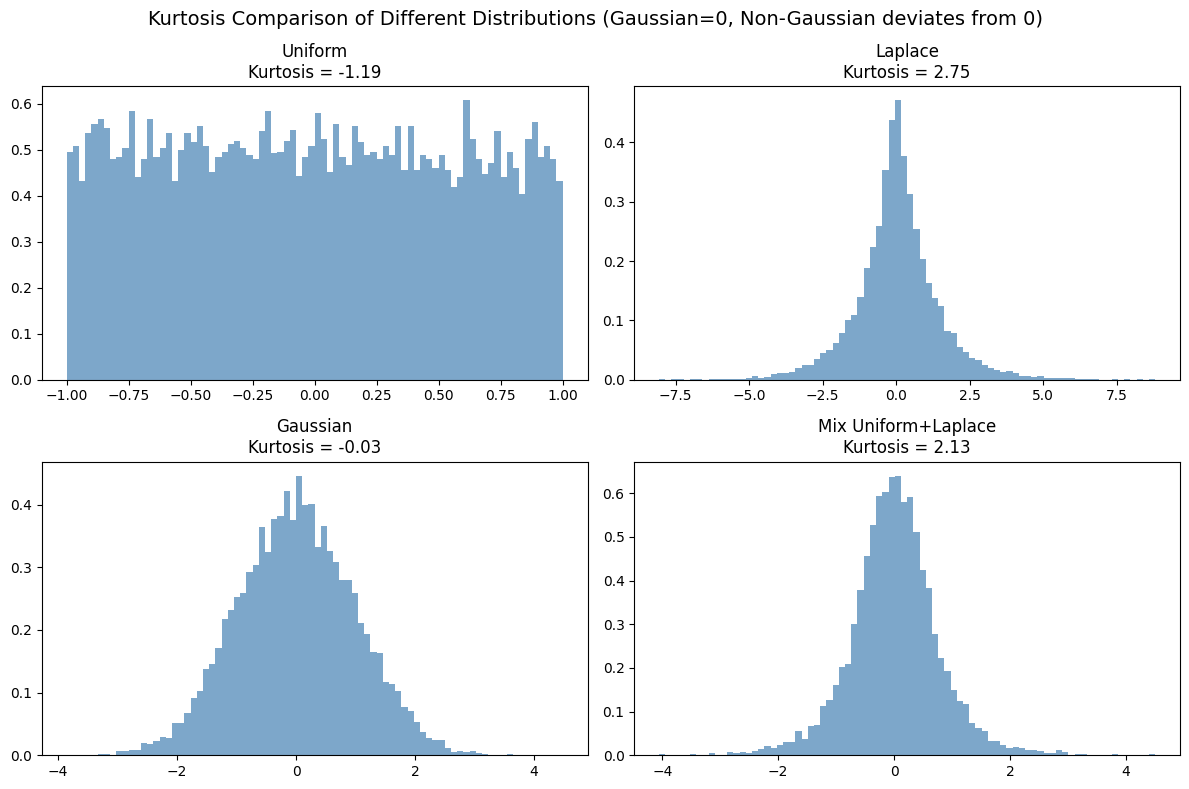

关键：混合信号峰度 → 0（更高斯），ICA 通过最大化非高斯性分离信号


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kurtosis

np.random.seed(42)
n = 10000

# 三种分布：均匀、拉普拉斯、高斯
x_uniform = np.random.uniform(-1, 1, n)
x_laplace = np.random.laplace(0, 1, n)
x_gaussian = np.random.randn(n)

# 混合后（中心极限定理的体现）
x_mix = (x_uniform + x_laplace) / 2

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, data, title in zip(axes.flat,
    [x_uniform, x_laplace, x_gaussian, x_mix],
    ['Uniform', 'Laplace', 'Gaussian', 'Mix Uniform+Laplace']):
    ax.hist(data, bins=80, density=True, alpha=0.7, color='steelblue')
    # 峰度是描述概率分布 尾部厚度 和 尖峰程度 的统计量。
    # 峰度是 非高斯性的经典度量 ，直接用于解释 FastICA 的核心思想
    ax.set_title(f'{title}\nKurtosis = {kurtosis(data):.2f}')
# 不同分布的峰度对比（高斯=0，非高斯偏离0）
plt.suptitle('Kurtosis Comparison of Different Distributions (Gaussian=0, Non-Gaussian deviates from 0)', fontsize=14)
plt.tight_layout()
plt.show()

print("关键：混合信号峰度 → 0（更高斯），ICA 通过最大化非高斯性分离信号")


### 2.2 数据预处理之一：中心化

  
**中心化是 ICA 预处理的必要步骤**，减去均值，让数据零中心，简化后续计算。原因：

1. **简化后续计算**：白化和 ICA 迭代都假设信号均值为零，中心化后协方差矩阵的计算更简洁
2. **数值稳定性**：去除直流偏置（DC offset），避免大均值影响数值精度
3. **不影响源信号恢复**：减去均值只是移除了每个混合信号的整体偏移量，最终可以通过逆操作加回

从代码验证可以看到：中心化前均值是某个非零值，中心化后均值变为接近 0（`≈ 0.000000`）。


In [6]:
# 沿用 Unit 1 的模拟数据
fs = 2000; 
t = np.arange(0, 1, 1/fs)
s1 = np.sin(2 * np.pi * 100 * t)
s2 = np.sin(2 * np.pi * 300 * t + 1.5)
s3 = np.sign(np.sin(2 * np.pi * 500 * t))
S = np.vstack([s1, s2, s3])

np.random.seed(42)
A = np.random.randn(3, 3)
X = A @ S

# 中心化
# 中心化后，每个样本的均值为 0，这使得后续的 ICA 过程更有效率。
X_centered = X - X.mean(axis=1, keepdims=True)  # axis=1: 沿样本维度计算均值, keepdims=True: 保持维度以便广播
print(f"中心化前均值: {np.array2string(X.mean(axis=1), precision=6)}")
print(f"中心化后均值: {np.array2string(X_centered.mean(axis=1), precision=6)}")
print("→ 均值归零 ✓")


中心化前均值: [ 0.000972 -0.000351 -0.000704]
中心化后均值: [-1.110223e-17  3.730349e-17 -8.881784e-18]
→ 均值归零 ✓


### 2.3 数据预处理之二：白化（Whitening）

白化 = 去相关 + 方差归一化。变换后满足：
$$E[Z Z^T] = I$$

即各通道方差为 1，互协方差为 0。

**为什么要白化？** 它把 ICA 的搜索空间从一个任意矩阵降为**正交矩阵**，大幅简化问题。

- 左边 （白化前）：数据点呈倾斜的椭圆形状
- 右边 （白化后）：数据点呈圆形（在 2 维是圆，3 维以上就是球）  

对 ICA 的意义:  
球状分布意味着搜索空间从 任意矩阵 降为 正交矩阵 （正交矩阵就是旋转矩阵）。原本需要搜索 9 个参数的一般矩阵，现在只需搜索3个旋转角度即可，这大幅简化FastICA 的求解过程。  
这段话的关键是：  
白化之后，数据已经被去相关，并且每个方向方差相同。所以 ICA 后面不用再负责“缩放”和“拉伸”，只需要负责“旋转方向”。

白化后协方差矩阵（应接近单位矩阵）:
[[ 1. -0.  0.]
 [-0.  1. -0.]
 [ 0. -0.  1.]]


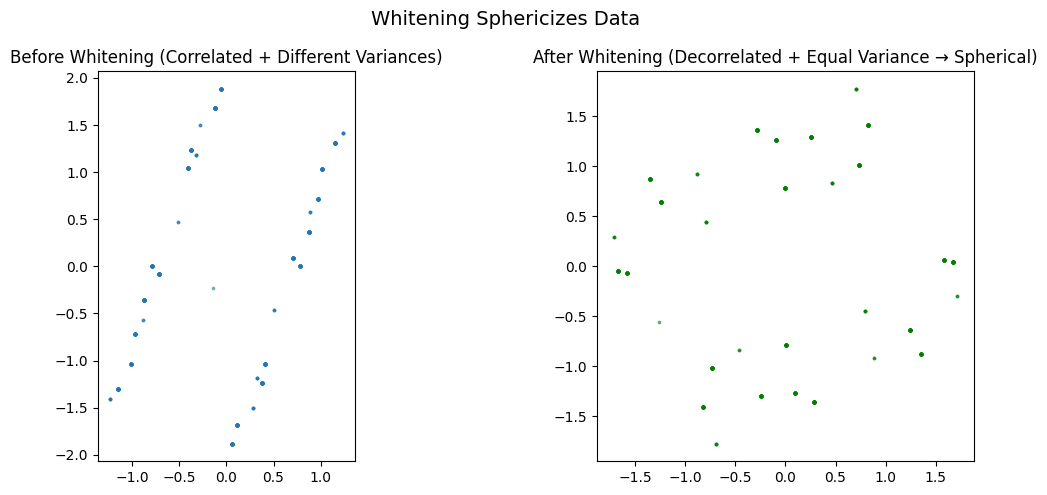

In [ ]:
def whiten(X):
    # 计算矩阵 X 的协方差矩阵
    cov = np.cov(X)
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    # 白化矩阵 = D^(-1/2) @ E^T
    D_inv_sqrt = np.diag(1.0 / np.sqrt(eigenvalues + 1e-10))
    whitening_matrix = D_inv_sqrt @ eigenvectors.T
    return whitening_matrix @ X, whitening_matrix

Z, W_white = whiten(X_centered)

# 验证
cov_Z = np.cov(Z)
print("白化后协方差矩阵（应接近单位矩阵）:")
print(np.array2string(cov_Z, precision=4, suppress_small=True)) # 禁止科学计数法

# 可视化对比：白化前 vs 白化后
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_centered[0, :500], X_centered[1, :500], alpha=0.5, s=3)
axes[0].set_title('Before Whitening (Correlated + Different Variances)')
axes[0].set_aspect('equal')
axes[1].scatter(Z[0, :500], Z[1, :500], alpha=0.5, s=3, color='green')
axes[1].set_title('After Whitening (Decorrelated + Equal Variance → Spherical)')
axes[1].set_aspect('equal')
fig.suptitle('Whitening Sphericizes Data', fontsize=14)
plt.tight_layout()
plt.show()


### 2.4 FastICA 核心：非高斯性度量

FastICA 用**负熵近似**作为非高斯性度量：

$$J(y) \propto [E\{G(y)\} - E\{G(\nu)\}]^2$$

其中 $\nu$ 是标准高斯变量，$G$ 是非二次函数。

常用 $G$ 函数：
| 函数 | $G(u)$ | 适用场景 |
|------|--------|---------|
| logcosh | $\frac{1}{a}\log\cosh(au)$ | 通用（默认） |
| exp | $-\exp(-u^2/2)$ | 超高斯（尖峰分布） |
| cube | $u^4/4$ | 基于峰度，对异常值敏感 |


In [20]:
from sklearn.decomposition import FastICA
import time

for fun in ['logcosh', 'exp', 'cube']:
    start = time.time()
    ica = FastICA(
        n_components=3,      # 独立成分的数量
        fun=fun,             # 用于近似负熵的对比函数
        random_state=42,     # 随机种子，保证结果可复现
        max_iter=2000        # 最大迭代次数
    )
    S_hat = ica.fit_transform(X.T).T
    elapsed = time.time() - start
    print(f"G={fun:8s}  迭代: {ica.n_iter_:3d}  耗时: {elapsed:.4f}s")

print("\n默认 logcosh 兼顾速度与鲁棒性。")


G=logcosh   迭代:   6  耗时: 0.0055s
G=exp       迭代:   6  耗时: 0.0019s
G=cube      迭代:   6  耗时: 0.0012s

默认 logcosh 兼顾速度与鲁棒性。


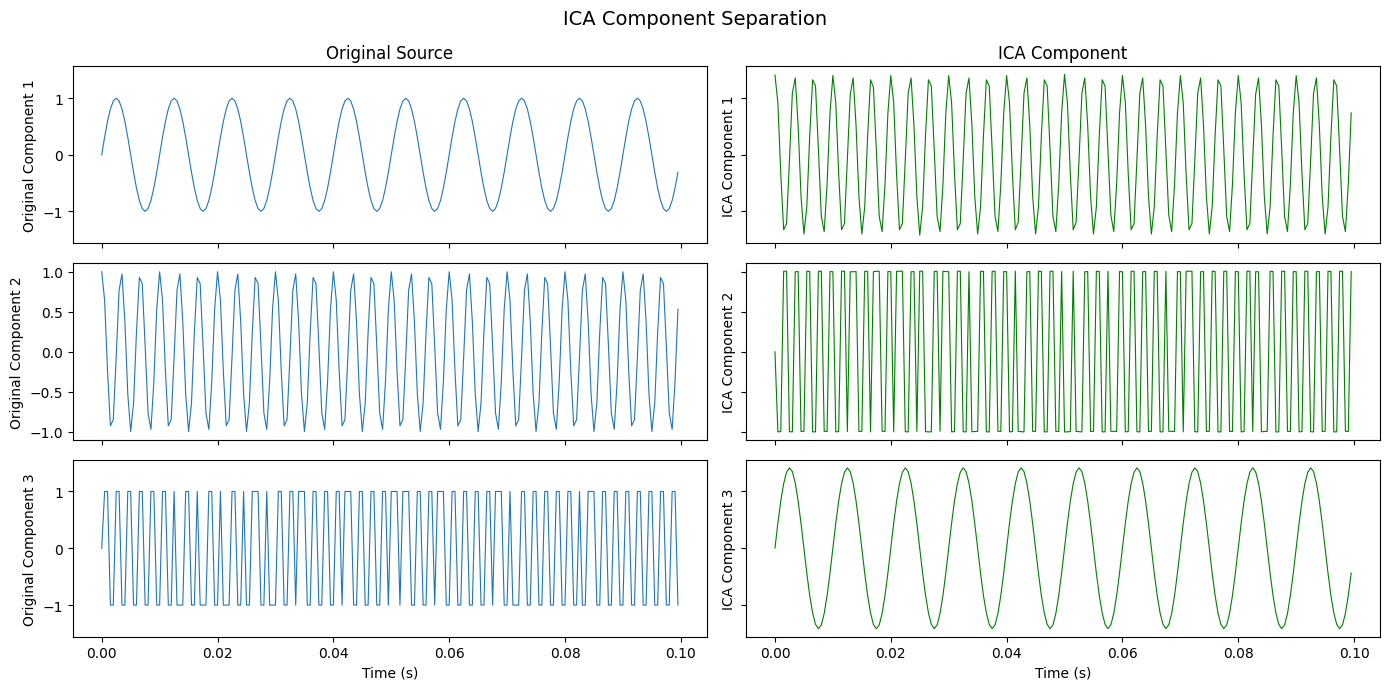

In [21]:
# 绘图
import matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 2, figsize=(14, 7), sharex=True, sharey='row')
for i in range(3):
    axes[i, 0].plot(t[:200], S[i, :200], linewidth=0.8)
    axes[i, 0].set_ylabel(f'Original Component {i+1}')
    axes[i, 1].plot(t[:200], S_hat[i, :200], linewidth=0.8, color='green')
    axes[i, 1].set_ylabel(f'ICA Component {i+1}')

axes[0, 0].set_title('Original Source')
axes[0, 1].set_title('ICA Component')
axes[-1, 0].set_xlabel('Time (s)')
axes[-1, 1].set_xlabel('Time (s)')
fig.suptitle('ICA Component Separation', fontsize=14)
plt.tight_layout()
plt.show()


### 2.5 FastICA 迭代过程（简化版）

核心循环（单个成分的提取）：
1. 随机初始化权重向量 $w$
2. $w^+ = E\{Z \cdot g(w^T Z)\} - E\{g'(w^T Z)\} \cdot w$
3. $w = w^+ / \|w^+\|$（归一化）
4. 与已找到的成分正交化（去相关）
5. 重复直到收敛


In [14]:
def fastica_single_component(Z, max_iter=1000, tol=1e-6):
    """提取单个独立成分的简化 FastICA 实现"""
    n, m = Z.shape
    w = np.random.randn(n)
    w = w / np.linalg.norm(w)

    for i in range(max_iter):
        w_old = w.copy()
        # 核心不动点迭代
        wX = w @ Z
        g = np.tanh(wX)           # G' = tanh（logcosh 的导数）
        gp = 1 - np.tanh(wX)**2   # G'' = 1 - tanh²
        w_new = (Z @ g) / m - np.mean(gp) * w
        w_new = w_new / np.linalg.norm(w_new)
        w = w_new
        if abs(abs(w @ w_old) - 1) < tol:
            break
    return w, i + 1

w_ic1, iters = fastica_single_component(Z)
print(f"提取第一个独立成分，{iters} 次迭代收敛")
print(f"权重向量: {np.array2string(w_ic1, precision=4)}")


提取第一个独立成分，22 次迭代收敛
权重向量: [ 0.8425  0.5225 -0.131 ]


### 2.6 完整 ICA 流程图

```text
原始数据 X
    │
    ▼
中心化 → X_centered（均值=0）
    │
    ▼
白化   → Z（协方差=I，球状分布）
    │
    ▼
FastICA 迭代
  ├─ 随机初始化 w
  ├─ 不动点迭代 w ← f(w)
  ├─ Gram-Schmidt 正交化（避免重复收敛）
  └─ 收敛判断
    │
    ▼
解混矩阵 W → 独立成分 S = W @ Z
```

### 2.7 成分数量怎么选？

在 EEG 中，成分数量 $k$ 的选择是一个权衡：

| $k$ 太少 | $k$ 太多 |
|----------|---------|
| 伪迹和脑信号混在同一成分中 | 脑信号过度拆分，出现噪声成分 |
| 剔除伪迹时误伤脑信号 | 人工识别负担增大 |

**经验法则：** 取通道数的 1/4 到 1/2。60 通道 EEG → 15-30 个成分。

### 🤔 思考题

- 不白化直接跑 ICA 会怎样？（试试跳过白化步骤）
- 为什么每次 FastICA 运行结果可能略有不同？

→ 进入 **Unit 3：EEG 伪迹识别**
